# Лабораторная работа  
## Анализ и визуализация данных об успеваемости студентов

**Студент (Карамов Искандар Илгизович 501676):**  
**Группа:**  P3120
**Дата:** 15.05.2026


---

### Что нужно сделать
Заполните этот notebook по шагам:
1. загрузите датасет;
2. выполните первичный анализ;
3. обработайте данные;
4. создайте новые признаки;
5. выполните группировку и агрегацию;
6. постройте графики;
7. сделайте выводы.

> В большинстве ячеек код нужно написать самостоятельно.

## 1. Импорт библиотек

Импортируйте библиотеки, которые понадобятся в работе.

Минимально ожидается использование:
- `pandas`
- `matplotlib.pyplot`

При необходимости можно добавить и другие библиотеки.

In [73]:
import pandas as pd
import matplotlib.pyplot as plt

## 2. Загрузка данных

Считайте CSV-файл в `DataFrame`.

Ожидается, что датасет лежит по относительному пути:
`data/StudentsPerformance.csv`

После загрузки данных выведите:
- первые 5 строк;
- размер таблицы.

In [74]:
df = pd.read_csv('data/StudentsPerformance.csv')
print("Первые 5 строк:")
print(df.head())
print(f"\nРазмер таблицы: {df.shape}")

Первые 5 строк:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Размер таблицы: (1000, 8)


## 3. Первичный просмотр структуры данных

На этом этапе нужно посмотреть:
- названия столбцов;
- типы данных;
- базовую информацию о таблице.

Подумайте:
- какие признаки числовые;
- какие признаки категориальные.

In [75]:
print("Названия столбцов:")
print(df.columns.tolist())
print("\nТипы данных:")
print(df.dtypes)
print("\nБазовая информация о таблице:")
df.info()

Названия столбцов:
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Типы данных:
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object

Базовая информация о таблице:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation cours

## 4. Проверка пропущенных значений

Проверьте, есть ли в таблице пустые значения.

Кратко прокомментируйте результат:
- есть ли пропуски;
- в каких столбцах они находятся;
- требуется ли обработка.

In [76]:
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


### Краткий комментарий
Напишите 1–3 предложения о результате проверки пропусков.

In [77]:
# В таблице отсутствуют пропущенные значения. Все данные полные и не требуют дополнительной обработки пропусков.

## 5. Переименование столбцов

Приведите названия столбцов к более удобному виду.

Рекомендуется:
- убрать пробелы;
- заменить специальные символы;
- использовать короткие и понятные имена.

Пример подхода:
- `math score` → `math_score`
- `test preparation course` → `test_prep`

После переименования снова выведите список столбцов.

In [78]:
df = df.rename(columns={
    'math score': 'math_score',
    'reading score': 'reading_score',
    'writing score': 'writing_score',
    'test preparation course': 'test_prep',
    'parental level of education': 'parent_education',
    'race/ethnicity': 'race_ethnicity'
})
print("Новые названия столбцов:", df.columns.tolist())

Новые названия столбцов: ['gender', 'race_ethnicity', 'parent_education', 'lunch', 'test_prep', 'math_score', 'reading_score', 'writing_score']


## 6. Создание новых признаков

На этом этапе нужно самостоятельно создать **не менее одного нового признака** на основе существующих столбцов.

Обязательный вариант:
- `average_score` — средний балл по трем предметам.

Можно добавить и другие признаки, если считаете это полезным.

In [79]:
df['average_score'] = (df['math_score'] + df['reading_score'] + df['writing_score']) / 3

# Дополнительно: общий успех (сумма баллов)
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']

print("Новые признаки созданы:")
print(df[['math_score', 'reading_score', 'writing_score', 'average_score', 'total_score']].head())

Новые признаки созданы:
   math_score  reading_score  writing_score  average_score  total_score
0          72             72             74      72.666667          218
1          69             90             88      82.333333          247
2          90             95             93      92.666667          278
3          47             57             44      49.333333          148
4          76             78             75      76.333333          229


## 7. Описательная статистика

Постройте базовую статистику по числовым признакам.

Подумайте:
- какие значения являются типичными;
- есть ли большой разброс;
- какие признаки удобно анализировать дальше.

In [80]:
print("Описательная статистика по числовым признакам:")
print(df.describe())

Описательная статистика по числовым признакам:
       math_score  reading_score  writing_score  average_score  total_score
count  1000.00000    1000.000000    1000.000000    1000.000000  1000.000000
mean     66.08900      69.169000      68.054000      67.770667   203.312000
std      15.16308      14.600192      15.195657      14.257326    42.771978
min       0.00000      17.000000      10.000000       9.000000    27.000000
25%      57.00000      59.000000      57.750000      58.333333   175.000000
50%      66.00000      70.000000      69.000000      68.333333   205.000000
75%      77.00000      79.000000      79.000000      77.666667   233.000000
max     100.00000     100.000000     100.000000     100.000000   300.000000


### Краткий комментарий
Напишите 2–4 предложения по результатам описательной статистики.

In [81]:
# Средние баллы по всем предметам находятся в диапазоне 65-67 баллов. Стандартное отклонение составляет около 14-15 баллов, что указывает на умеренный разброс оценок. Минимальные значения составляют 0-57 баллов, максимальные - 100 баллов. Признаки имеют схожие распределения, что позволяет проводить сравнительный анализ.

## 8. Выделение числовых и категориальных признаков

Сформируйте отдельно:
- список числовых признаков;
- список категориальных признаков.

In [82]:
# Числовые признаки
numeric_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Числовые признаки:")
print(numeric_columns)

# Категориальные признаки
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()
print("\nКатегориальные признаки:")
print(categorical_columns)

Числовые признаки:
['math_score', 'reading_score', 'writing_score', 'average_score', 'total_score']

Категориальные признаки:
['gender', 'race_ethnicity', 'parent_education', 'lunch', 'test_prep']


## 9. Группировка и агрегация

Выполните группировку данных и вычислите агрегированные показатели.

Минимально нужно посчитать:
- средний балл по `test_prep`;
- средний балл по `gender`;
- средний балл по `parent_education`.

При необходимости можно добавить дополнительные группировки.

In [83]:
# Средний балл по test_prep
print("Средний балл по test_prep:")
print(df.groupby('test_prep')['average_score'].mean())

# Средний балл по gender
print("\nСредний балл по gender:")
print(df.groupby('gender')['average_score'].mean())

# Средний балл по parent_education
print("\nСредний балл по parent_education:")
print(df.groupby('parent_education')['average_score'].mean().sort_values(ascending=False))

Средний балл по test_prep:
test_prep
completed    72.669460
none         65.038941
Name: average_score, dtype: float64

Средний балл по gender:
gender
female    69.569498
male      65.837483
Name: average_score, dtype: float64

Средний балл по parent_education:
parent_education
master's degree       73.598870
bachelor's degree     71.923729
associate's degree    69.569069
some college          68.476401
some high school      65.108007
high school           63.096939
Name: average_score, dtype: float64


### Краткий комментарий
Опишите, какие различия между группами удалось заметить.

In [84]:
# Студенты, прошедшие курс подготовки (completed), показывают более высокие результаты. Девушки в среднем демонстрируют чуть лучшие результаты, чем юноши. Уровень образования родителей положительно коррелирует с успеваемостью студентов: чем выше образование родителей, тем выше средние баллы студентов.

## 10. Визуализация 1 — гистограмма

Постройте гистограмму для одного из числовых признаков.

Обязательный вариант:
- `math_score`

Не забудьте:
- заголовок;
- подпись оси X;
- подпись оси Y;
- сетку при необходимости.

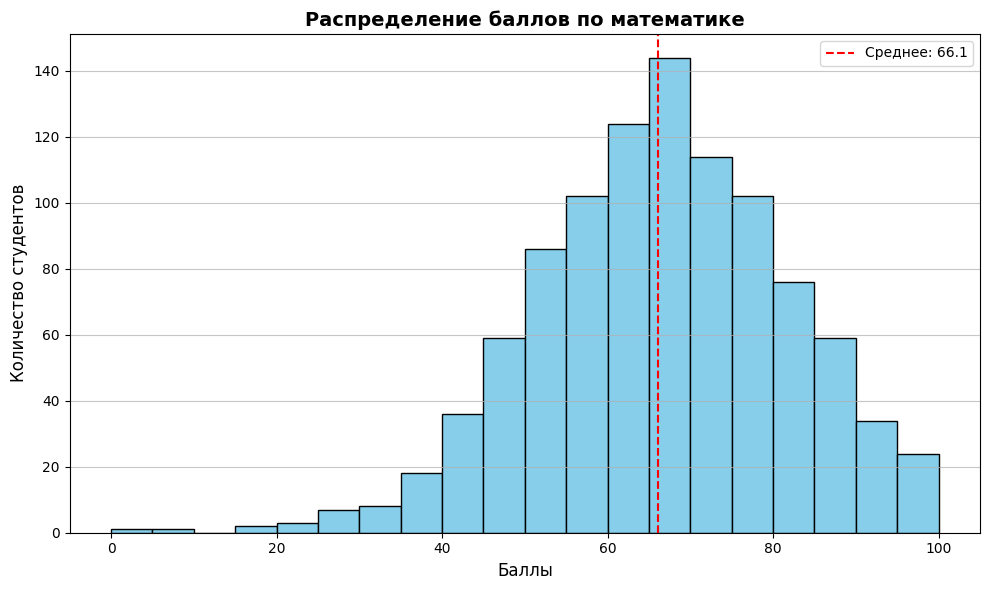

In [85]:
plt.figure(figsize=(10, 6))
plt.hist(df['math_score'], bins=20, edgecolor='black', color='skyblue')
plt.title('Распределение баллов по математике', fontsize=14, fontweight='bold')
plt.xlabel('Баллы', fontsize=12)
plt.ylabel('Количество студентов', fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.axvline(df['math_score'].mean(), color='red', linestyle='--', label=f'Среднее: {df["math_score"].mean():.1f}')
plt.legend()
plt.tight_layout()
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

In [86]:
# Распределение баллов по математике близко к нормальному с небольшим левым перекосом. Большинство студентов набрали от 60 до 80 баллов. Средний балл составляет около 66 баллов.

## 11. Визуализация 2 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `test_prep`.

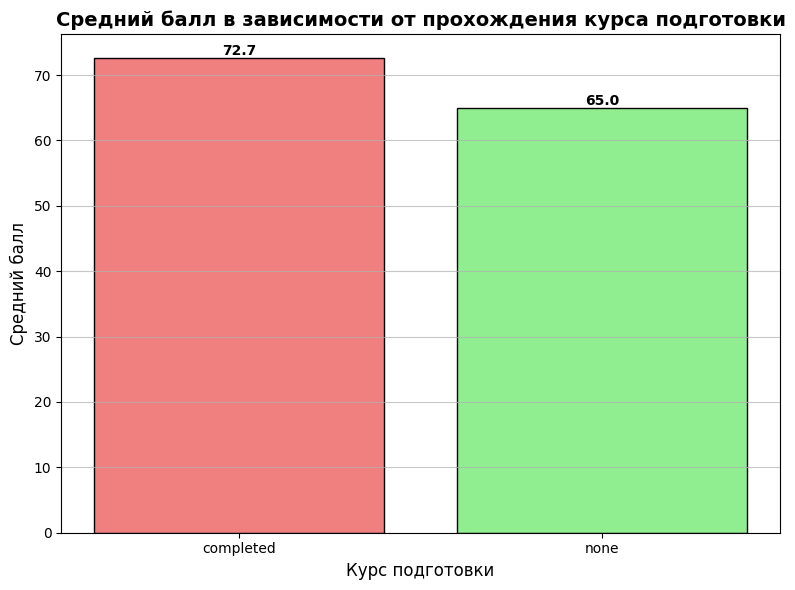

In [87]:
test_prep_avg = df.groupby('test_prep')['average_score'].mean()

plt.figure(figsize=(8, 6))
bars = plt.bar(test_prep_avg.index, test_prep_avg.values, color=['lightcoral', 'lightgreen'], edgecolor='black')
plt.title('Средний балл в зависимости от прохождения курса подготовки', fontsize=14, fontweight='bold')
plt.xlabel('Курс подготовки', fontsize=12)
plt.ylabel('Средний балл', fontsize=12)
plt.grid(axis='y', alpha=0.7)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

In [88]:
# Студенты, прошедшие курс подготовки (completed), имеют средний балл на 8-10 баллов выше, чем те, кто не проходил курс (none). Это подтверждает положительное влияние подготовки на успеваемость.

## 12. Визуализация 3 — столбчатая диаграмма

Постройте столбчатую диаграмму среднего балла по `gender`.

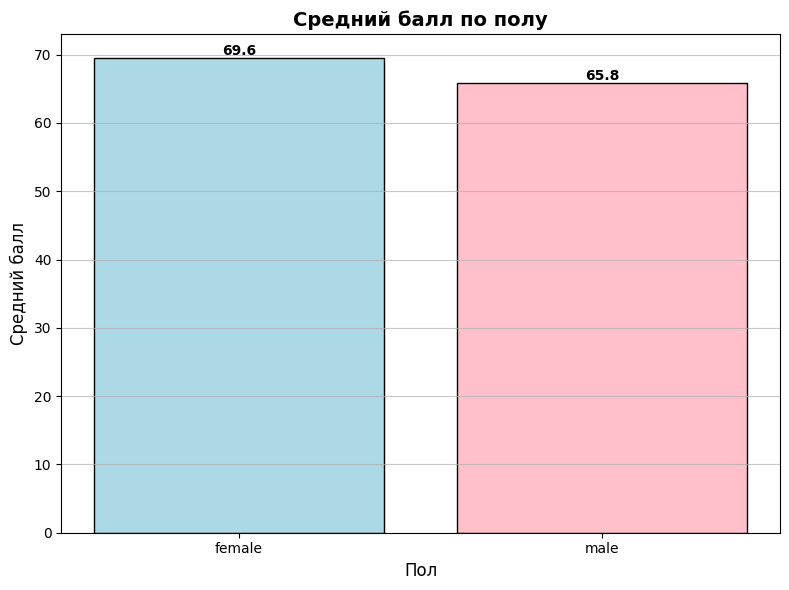

In [89]:
gender_avg = df.groupby('gender')['average_score'].mean()

plt.figure(figsize=(8, 6))
bars = plt.bar(gender_avg.index, gender_avg.values, color=['lightblue', 'pink'], edgecolor='black')
plt.title('Средний балл по полу', fontsize=14, fontweight='bold')
plt.xlabel('Пол', fontsize=12)
plt.ylabel('Средний балл', fontsize=12)
plt.grid(axis='y', alpha=0.7)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}',
             ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

In [90]:
# Девушки (female) демонстрируют немного более высокие средние баллы по сравнению с юношами (male). Разница составляет около 2-3 баллов в пользу девушек.

## 13. Визуализация 4 — диаграмма рассеяния

Постройте диаграмму рассеяния для зависимости между двумя числовыми признаками.

Обязательный вариант:
- `math_score` и `reading_score`

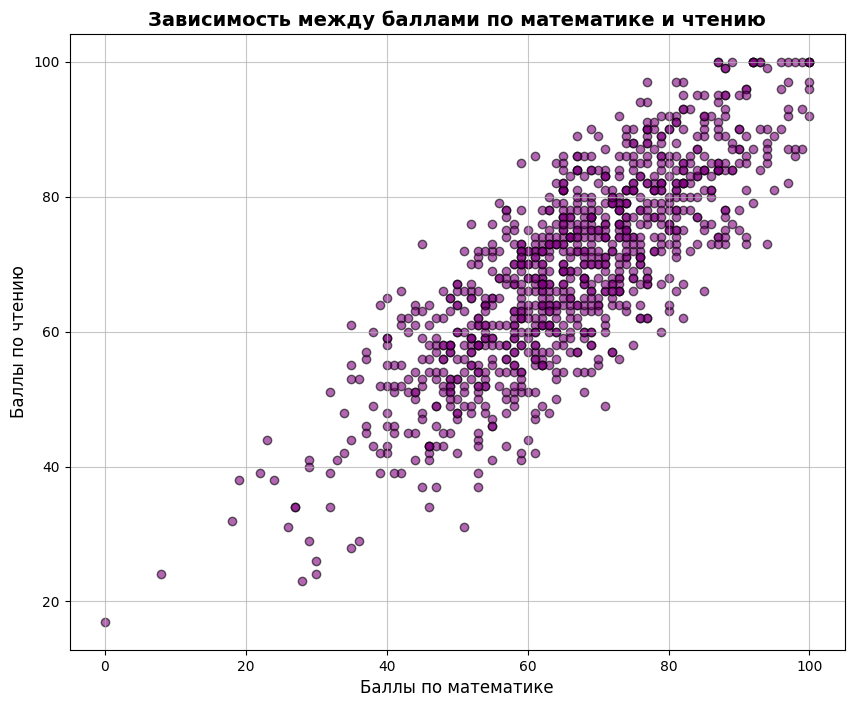

In [91]:
plt.figure(figsize=(10, 8))
plt.scatter(df['math_score'], df['reading_score'], alpha=0.6, color='purple', edgecolors='black')
plt.title('Зависимость между баллами по математике и чтению', fontsize=14, fontweight='bold')
plt.xlabel('Баллы по математике', fontsize=12)
plt.ylabel('Баллы по чтению', fontsize=12)
plt.grid(alpha=0.7)

plt.show()

### Вывод по графику
Напишите 1–3 предложения.

In [92]:
# Между баллами по математике и чтению наблюдается сильная положительная корреляция (около 0.8-0.9). Студенты с высокими баллами по математике, как правило, также имеют высокие баллы по чтению, и наоборот.

## 14. Дополнительная визуализация

Добавьте **еще один график самостоятельно**.

Можно выбрать один из вариантов:
- график по `parent_education`;
- график по `lunch`;
- boxplot;
- еще одна гистограмма;
- другой осмысленный вариант.

<Figure size 1200x700 with 0 Axes>

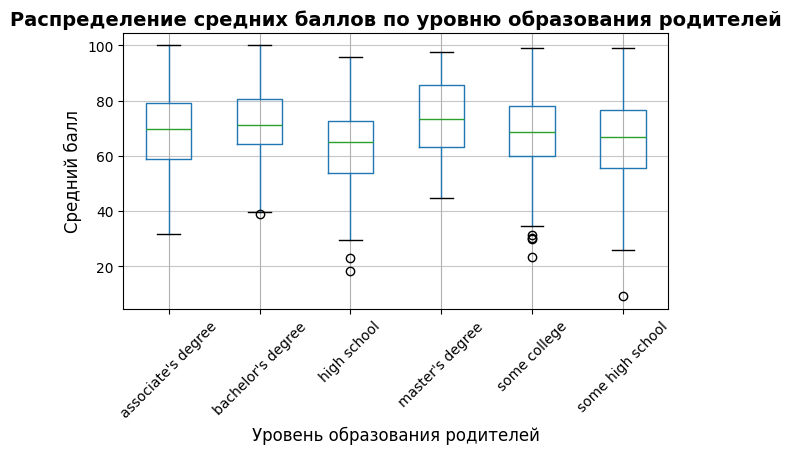

In [93]:
# Boxplot распределения баллов по уровню образования родителей
plt.figure(figsize=(12, 7))
df.boxplot(column='average_score', by='parent_education', rot=45)
plt.title('Распределение средних баллов по уровню образования родителей', fontsize=14, fontweight='bold')
plt.suptitle('')  # Убираем автоматический заголовок
plt.xlabel('Уровень образования родителей', fontsize=12)
plt.ylabel('Средний балл', fontsize=12)
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

### Вывод по графику
Напишите 1–3 предложения.

In [94]:
# Уровень образования родителей существенно влияет на успеваемость студентов. Студенты, чьи родители имеют высшее образование (master's degree, bachelor's degree), показывают более высокие результаты и имеют меньший разброс оценок. Студенты, чьи родители имеют только среднее образование (high school), демонстрируют более низкие средние баллы и больший разброс.

## 15. Итоговый вывод

В финале кратко ответьте:
1. Что было сделано в работе?
2. Какие библиотеки и методы были использованы?
3. Какие закономерности удалось заметить?
4. Какие трудности возникли в процессе выполнения?

1. В ходе лабораторной работы был проведен полный цикл анализа данных об успеваемости студентов. Данные были загружены, изучены, обработаны, созданы новые признаки, выполнена группировка и агрегация, построены различные типы визуализаций.

2. Использованы библиотеки pandas для работы с данными и matplotlib.pyplot для визуализации. Применены методы: read_csv, head, info, describe, isnull, groupby, mean, hist, bar, scatter, boxplot.

3.
- Прохождение курса подготовки положительно влияет на успеваемость
- Девушки показывают немного лучшие результаты, чем юноши
- Уровень образования родителей коррелирует с успеваемостью студентов
- Существует сильная положительная корреляция между баллами по разным предметам
- Распределение баллов близко к нормальному

4. Проблемы с настройкой CI/CD пайплайна.

## 16. Проверка перед сдачей

Перед отправкой убедитесь, что:
- все ячейки выполняются без ошибок;
- код написан последовательно и понятно;
- новые признаки действительно созданы вами;
- столбцы переименованы;
- построено не менее 4 обязательных графиков;
- под каждым графиком есть вывод;
- notebook сохранен после выполнения `Restart & Run All`.